## Ride Knox 2025: Did ridership change after the July price increase?

**Part 1: Clean and Explore Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
def clean_trips(path, remove_test_station=False):
    """Load and clean a Ride Knox trip file. Prints a row-count audit trail."""
    trips = pd.read_csv(path)
    n0 = len(trips)
    print(f"{path}: {n0:,} raw rows")

    trips = trips.drop_duplicates()
    print(f"  after dropping exact duplicates: {len(trips):,} "
          f"(-{n0 - len(trips)})")

    trips = trips.copy()
    trips["rider_type"] = (trips["rider_type"].str.strip()
                                              .str.lower()
                                              .str.replace(" ", "_"))
    print(f"  rider_type categories: {sorted(trips['rider_type'].unique())}")

    if remove_test_station:
        before = len(trips)
        trips = trips[trips["start_station_id"] != "S99"]
        print(f"  after removing S99 test-station trips: {len(trips):,} "
              f"(-{before - len(trips)})")

    trips["start_time"] = pd.to_datetime(trips["start_time"])
    trips["end_time"] = pd.to_datetime(trips["end_time"])
    trips["duration_min"] = ((trips["end_time"] - trips["start_time"])
                             .dt.total_seconds() / 60)
    trips["missing_end_time"] = trips["end_time"].isna()
    print(f"  trips with missing end_time (kept, flagged): "
          f"{trips['missing_end_time'].sum():,}")

    # Keep rows whose duration is unknown OR within 1 min - 24 h.
    # The explicit isna() term matters: a bare (d >= 1) & (d <= 1440) would
    # silently drop every missing-end_time row from the counts too.
    d = trips["duration_min"]
    keep = d.isna() | ((d >= 2) & (d <= 1440)) 
    
    before = len(trips)
    trips = trips[keep].copy()
    print(f"  after removing durations outside 2 min-24 h: {len(trips):,} "
          f"(-{before - len(trips)})")

    trips["month"] = trips["start_time"].dt.month
    trips["is_weekend"] = trips["start_time"].dt.dayofweek >= 5
    return trips

trips_2025 = clean_trips("trips_2025.csv", remove_test_station=True)

trips_2025.csv: 250,600 raw rows
  after dropping exact duplicates: 250,000 (-600)
  rider_type categories: ['casual', 'member']
  after removing S99 test-station trips: 249,737 (-263)
  trips with missing end_time (kept, flagged): 0
  after removing durations outside 2 min-24 h: 247,844 (-1893)


In [3]:
stations_2025 = pd.read_excel("stations.xlsx")
print(stations_2025.shape)
print(stations_2025.columns)

(24, 7)
Index(['station_id', 'station_name', 'neighborhood', 'latitude', 'longitude',
       'docks', 'year_installed'],
      dtype='str')


In [6]:
merged_2025 = pd.merge(
    trips_2025, stations_2025,
    left_on="start_station_id", right_on="station_id",
    how="left",
)
assert len(merged_2025) == len(trips_2025)  


print(f"Shape of trips: {trips_2025.shape}")
print(f"Shape of merged: {merged_2025.shape}")

Shape of trips: (247844, 12)
Shape of merged: (247844, 19)


In [8]:
display(merged_2025.sample(5))

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type,duration_min,missing_end_time,month,is_weekend,station_id,station_name,neighborhood,latitude,longitude,docks,year_installed
243098,T0021496,2025-12-17 10:37:56,2025-12-17 10:51:17,S01,Market Square,S01,member,electric,13.350000,False,12,False,S01,Market Square,Downtown,35.9649,-83.9197,20,2022
178192,T0072774,2025-08-27 18:07:01,2025-08-27 18:14:26,S06,Hodges Library,NaN,member,classic,7.416667,False,8,False,S06,Hodges Library,UT Campus,35.9553,-83.9264,24,2022
80903,T0082613,2025-05-13 12:10:04,2025-05-13 12:24:53,S06,Hodges Library,S09,casual,classic,14.816667,False,5,False,S06,Hodges Library,UT Campus,35.9553,-83.9264,24,2022
239947,T0072924,2025-12-08 07:54:16,2025-12-08 08:15:31,S08,Student Union - UT,S01,casual,classic,21.250000,False,12,False,S08,Student Union - UT,UT Campus,35.9560,-83.9295,24,2022
75925,T0240749,2025-05-08 09:56:57,2025-05-08 10:14:46,S04,Old City - Jackson Ave,S05,member,classic,17.816667,False,5,False,S04,Old City - Jackson Ave,Old City,35.9721,-83.9151,16,2022


In [9]:
merged_2025.describe()

,start_time,end_time,duration_min,month,latitude,longitude,docks,year_installed
count,247844,247844,247844.000000,247844.000000,247844.000000,247844.000000,247844.000000,247844.000000
mean,2025-06-29 10:29:01.524757,2025-06-29 10:45:56.842820,16.921968,6.427426,35.961169,-83.923639,16.458797,2022.474936
min,2025-01-01 00:06:48,2025-01-01 00:19:16,2.000000,1.000000,35.939000,-83.979000,10.000000,2022.000000
25%,2025-04-22 13:07:04.250000,2025-04-22 13:31:59.750000,9.133333,4.000000,35.955300,-83.929500,12.000000,2022.000000
50%,2025-06-25 08:02:03,2025-06-25 08:16:58.500000,13.733333,6.000000,35.957500,-83.925600,16.000000,2022.000000
75%,2025-09-06 17:19:18.750000,2025-09-06 17:44:40.250000,20.900000,9.000000,35.964900,-83.918600,20.000000,2023.000000
max,2025-12-31 23:42:04,2026-01-01 00:37:04,180.000000,12.000000,35.986300,-83.868000,24.000000,2025.000000
std,NaN,NaN,12.025300,2.909465,0.008874,0.012757,4.873412,0.735692


**Part 2: Analyze data, determine if ridership changed over 2025**

In [ ]:
month_rider_type = merged_2025.groupby(['month', 'rider_type']).size().unstack('month')

month_rider_type


# TODO: casual share of each month's trips 
casual_monthly = month_rider_type.loc['casual'] /month_rider_type.sum() * 100
print("Percentage of casual riders each month:", casual_monthly)

# TODO: June -> July percent change for each rider type
change_june_to_july = (month_rider_type[7] - month_rider_type[6]) / month_rider_type[6] * 100
change_june_to_july


Percentage of casual riders each month: month
1     43.565733
2     42.679527
3     43.462163
4     44.272885
5     44.614501
6     44.197057
7     33.764304
8     30.374345
9     27.403951
10    25.545840
11    24.425626
12    22.738816
dtype: float64


rider_type
casual   -34.221193
member     2.201330
dtype: float64

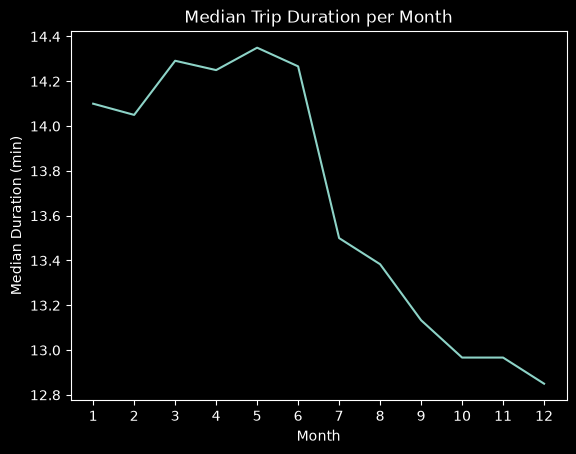

<Figure size 640x480 with 0 Axes>

In [13]:
# TODO: median duration per month, then a labeled line chart of it
median_duration = merged_2025.groupby('month')['duration_min'].median()

#matplotlib already imported

plt.plot(median_duration)
plt.xlabel('Month')
plt.xticks(range(1, 13))
plt.ylabel('Median Duration (min)')
plt.title('Median Trip Duration per Month')
plt.show()

plt.savefig('./charts/median_trip_duration_for_2025.png')

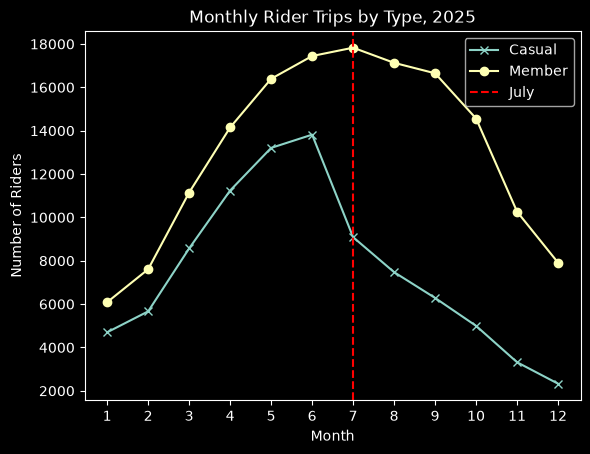

In [ ]:
# TODO: two-line chart with legend, markers, and axvline at month 7
#          (plot from your Part 5a table -- rider types are rows)


plt.plot(month_rider_type.loc['casual'], marker='x', label='Casual')
plt.plot(month_rider_type.loc['member'], marker='o', label='Member')
plt.axvline(x=7, color='r', linestyle='--', label='July')
plt.xlabel('Month')
plt.xticks(range(1, 13))
plt.ylabel('Number of Riders')
plt.title('Monthly Rider Trips by Type, 2025')
plt.legend()


# TODO: savefig, then show
plt.savefig('./charts/monthly_rider_counts_2025.png')
plt.show()


## Limitations
1. Observational comparisons: weather, marketing, and town events are uncontrolled for, so "price increase in July" is an interpertation of the data.
2. Some trip durations are inaccurate due to lack of docking resources at some stations, making the rider behavior less clear.
3. No data from previous years to compare trends to, does ridership usually fall in second half of the year?